# Taller 2 - obtención de los datos


In [ ]:
%pip install matplotlib pandas yfinance pandas_datareader

/Users/david/personal-repos/python-sandbox/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# ─── Configuración ───────────────────────────────────────────────────────────
# True  → usa "Adj Close" (precio ajustado por dividendos y splits)
# False → usa "Close"    (precio de cierre sin ajustar)
USE_ADJUSTED_CLOSE = False

# Frecuencia de descarga: "1d" → diario | "1wk" → semanal
FREQUENCY = "1d"
# ─────────────────────────────────────────────────────────────────────────────

symbols = ["SO", "DUK", "JNJ", "MRK", "PG", "KO", "WMT", "VZ", "T", "CVX"]
price_col = "Adj Close" if USE_ADJUSTED_CLOSE else "Close"

print(
    f"Obteniendo datos históricos con yfinance (columna: {price_col}, frecuencia: {FREQUENCY})..."
)
try:
    data = yf.download(
        symbols,
        start="2014-01-01",
        end="2025-01-01",
        auto_adjust=False,
        interval=FREQUENCY,
    )
    if not data.empty:
        price_data = data[price_col]
        price_data.index = pd.to_datetime(price_data.index)
        price_data = price_data.sort_index(ascending=True)

        # Filtrar datos: desde enero de 2015 hasta diciembre de 2024
        price_data = price_data.loc["2015-01-01":"2024-12-31"]
        # Excluir el año 2020
        price_data = price_data[price_data.index.year != 2020]

        print("\nPrimeras 5 filas de los datos de precios (filtrados con yfinance):")
        display(price_data.head())
        print("\nÚltimas 5 filas de los datos de precios (filtrados con yfinance):")
        display(price_data.tail())

        # Visualizar los precios de cierre
        plt.figure(figsize=(14, 7))
        for symbol in symbols:
            if symbol in price_data.columns:
                plt.plot(price_data.index, price_data[symbol], label=symbol)
        plt.title(
            f"Precios ({price_col}) de Acciones (yfinance: 2015-2024, excluyendo 2020)"
        )
        plt.xlabel("Fecha")
        plt.ylabel(f"Precio {price_col} (USD)")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"No se encontraron datos para los símbolos: {', '.join(symbols)}.")
except Exception as e:
    print(f"Error al obtener datos con yfinance: {e}")

In [ ]:
# Guardar datos de acciones en CSV
output_filename = "data_acciones.csv"

try:
    df_to_save = price_data.copy()
    df_to_save.index = df_to_save.index.date
    df_to_save.to_csv(output_filename, index=True)
    print(f"Datos de acciones guardados en '{output_filename}'")
except Exception as e:
    print(f"Error al guardar los datos de acciones: {e}")

Datos de acciones guardados en 'data_acciones.csv'


## Punto 2: Obtención de la Tasa Libre de Riesgo (Treasuries a 10 años)

Para el cálculo del modelo de Markowitz, es fundamental una tasa libre de riesgo. Utilizaremos la tasa de los Treasuries de Estados Unidos a 10 años, que se puede obtener de la base de datos de la Reserva Federal (FRED) a través de la librería `pandas_datareader`. El código del indicador para la tasa de 10 años en FRED es `DGS10`.


In [ ]:
symbol = "IVV"
price_col = "Adj Close" if USE_ADJUSTED_CLOSE else "Close"

print(
    f"Obteniendo datos históricos para {symbol} con yfinance (columna: {price_col}, frecuencia: {FREQUENCY})..."
)
try:
    data_ivv = yf.download(
        symbol,
        start="2014-01-01",
        end="2025-01-01",
        auto_adjust=False,
        interval=FREQUENCY,
    )
    if not data_ivv.empty:
        price_data_ivv = data_ivv[price_col]
        price_data_ivv.index = pd.to_datetime(price_data_ivv.index)
        price_data_ivv = price_data_ivv.sort_index(ascending=True)

        # Filtrar datos: desde enero de 2015 hasta diciembre de 2024
        price_data_ivv = price_data_ivv.loc["2015-01-01":"2024-12-31"]
        # Excluir el año 2020
        price_data_ivv = price_data_ivv[price_data_ivv.index.year != 2020]

        print(f"\nPrimeras 5 filas de los datos de precios de {symbol}:")
        display(price_data_ivv.head())
        print(f"\nÚltimas 5 filas de los datos de precios de {symbol}:")
        display(price_data_ivv.tail())

        # Visualizar los precios
        plt.figure(figsize=(14, 7))
        plt.plot(price_data_ivv.index, price_data_ivv, label=symbol)
        plt.title(
            f"Precios ({price_col}) de {symbol} (yfinance: 2015-2024, excluyendo 2020)"
        )
        plt.xlabel("Fecha")
        plt.ylabel(f"Precio {price_col} (USD)")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"No se encontraron datos para el símbolo: {symbol}.")
except Exception as e:
    print(f"Error al obtener datos con yfinance: {e}")

In [ ]:
# Guardar datos de IVV en CSV
output_filename_ivv = "data_ivv.csv"

try:
    df_ivv_to_save = price_data_ivv.copy()
    df_ivv_to_save.index = df_ivv_to_save.index.date
    df_ivv_to_save.to_csv(output_filename_ivv, index=True)
    print(f"Datos de {symbol} guardados en '{output_filename_ivv}'")
except Exception as e:
    print(f"Error al guardar los datos de {symbol}: {e}")

Datos de IVV guardados en 'data_ivv.csv'


Obteniendo la tasa de los Treasuries a 10 años desde FRED...

Primeras 5 filas de la tasa libre de riesgo (Treasuries a 10 años):


,DGS10
DATE,
2015-01-02,2.12
2015-01-05,2.04
2015-01-06,1.97
2015-01-07,1.96
2015-01-08,2.03



Últimas 5 filas de la tasa libre de riesgo (Treasuries a 10 años):


,DGS10
DATE,
2024-12-24,4.59
2024-12-26,4.58
2024-12-27,4.62
2024-12-30,4.55
2024-12-31,4.58


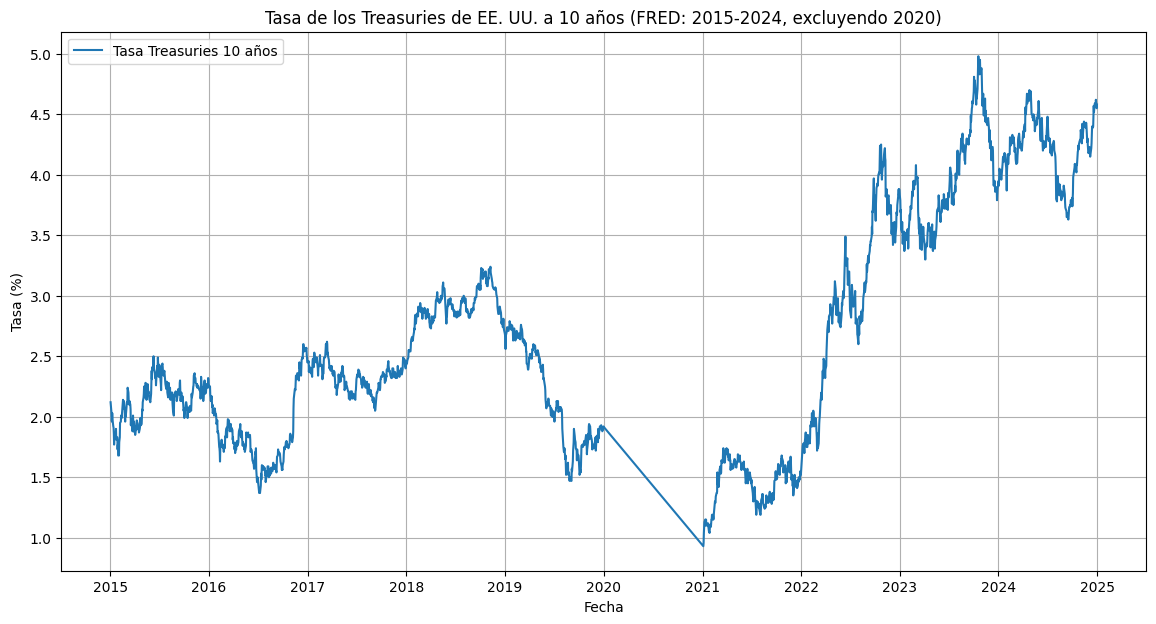

In [ ]:
import datetime

import pandas_datareader as pdr

print("Obteniendo la tasa de los Treasuries a 10 años desde FRED...")

# Definir el período de tiempo (similar al de las acciones, para comparabilidad)
start_date = datetime.datetime(2015, 1, 1)
end_date = datetime.datetime(2024, 12, 31)

try:
    # Obtener datos de la tasa de Treasuries a 10 años (DGS10) desde FRED
    # El `data_source` 'fred' es para la Federal Reserve Economic Data
    risk_free_rate = pdr.get_data_fred("DGS10", start=start_date, end=end_date)

    # Limpiar y preparar los datos
    risk_free_rate = risk_free_rate.dropna()  # Eliminar valores nulos
    risk_free_rate.index = pd.to_datetime(risk_free_rate.index)
    risk_free_rate = risk_free_rate.sort_index(ascending=True)

    # Excluir el año 2020 (si aplica en los datos de la tasa libre de riesgo)
    risk_free_rate = risk_free_rate[risk_free_rate.index.year != 2020]

    print("\nPrimeras 5 filas de la tasa libre de riesgo (Treasuries a 10 años):")
    display(risk_free_rate.head())
    print("\nÚltimas 5 filas de la tasa libre de riesgo (Treasuries a 10 años):")
    display(risk_free_rate.tail())

    # Visualizar la tasa libre de riesgo
    plt.figure(figsize=(14, 7))
    plt.plot(
        risk_free_rate.index, risk_free_rate["DGS10"], label="Tasa Treasuries 10 años"
    )
    plt.title(
        "Tasa de los Treasuries de EE. UU. a 10 años (FRED: 2015-2024, excluyendo 2020)"
    )
    plt.xlabel("Fecha")
    plt.ylabel("Tasa (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Error al obtener la tasa libre de riesgo de FRED: {e}")


In [ ]:
# Guardar datos de bonos del tesoro en CSV
output_filename_rf = "data_bonos_tesoro.csv"

try:
    df_rf_to_save = risk_free_rate.copy()
    df_rf_to_save.index = df_rf_to_save.index.date
    df_rf_to_save.to_csv(output_filename_rf, index=True)
    print(f"Datos de bonos del tesoro guardados en '{output_filename_rf}'")
except Exception as e:
    print(f"Error al guardar los datos de bonos del tesoro: {e}")

Datos de bonos del tesoro guardados en 'data_bonos_tesoro.csv'
